# Figure - zoom

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from netCDF4 import Dataset

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
# DEM INFO
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

with Dataset(ERW_TOPO_FILE) as dem:
    sky_view_factor = dem['sky_view_factor'][:].astype(np.float64)
    dem = dem['dem'][:].astype(np.float64)

In [3]:
with Dataset(ERW_TOPO_FILE) as s:
    slope = s['slope'][:].astype(np.float64)

In [4]:
d = xr.open_dataset(ERW_TOPO_FILE)

# LOAD SW DATA

In [5]:
# LOAD in files
import os
save_dir = 'sw-spatial-data-22'

# Loda Main
mean_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mean_dsw3.nc'))
mean_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mean_dsw1.nc'))
mean_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mean_ghi.nc'))
# Load January
jan_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_jan_dsw3.nc'))
jan_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_jan_dsw1.nc'))
jan_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_jan_ghi.nc'))
# Load February
feb_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb_dsw3.nc'))
feb_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb_dsw1.nc'))
feb_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb_ghi.nc'))
# Load March
mar_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar_dsw3.nc'))
mar_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar_dsw1.nc'))
mar_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar_ghi.nc'))
# Load April
apr_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr_dsw3.nc'))
apr_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr_dsw1.nc'))
apr_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr_ghi.nc'))
# Load May
may_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may_dsw3.nc'))
may_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may_dsw1.nc'))
may_ghi  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may_ghi.nc'))

# May 1st
may_dsw3_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may1_dsw3.nc'))
may_dsw1_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may1_dsw1.nc'))
may_ghi_day  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_may1_ghi.nc'))

# April 1st
apr_dsw3_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr1_dsw3.nc'))
apr_dsw1_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr1_dsw1.nc'))
apr_ghi_day  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_apr1_ghi.nc'))

# Load February 1st
feb_dsw3_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb1_dsw3.nc'))
feb_dsw1_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb1_dsw1.nc'))
feb_ghi_day  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_feb1_ghi.nc'))

# Load March 1st
mar_dsw3_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar1_dsw3.nc'))
mar_dsw1_day = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar1_dsw1.nc'))
mar_ghi_day  = xr.open_dataset(os.path.join(save_dir, 'sw_spatial_mar1_ghi.nc'))

In [6]:
#calculate month differences

# calculate main differences
dsw3_base = (mean_dsw3['dsw3'] - mean_ghi['ghi'])
dsw3_shade = (mean_dsw3['dsw3'] - mean_dsw1['dsw1'])
dsw1_base = (mean_dsw1['dsw1'] - mean_ghi['ghi'])
# dsw3_base = (mean_dsw3 - mean_ghi)
# dsw3_shade = (mean_dsw3 - mean_dsw1)
# dsw1_base = (mean_dsw1 - mean_ghi)

# January difference
jan1 = jan_dsw3 - jan_ghi
jan2 = jan_dsw3 - jan_dsw1
jan3 = jan_dsw1 - jan_ghi
# February differences
feb1 = feb_dsw3 - feb_ghi
feb2 = feb_dsw3 - feb_dsw1
feb3 = feb_dsw1 - feb_ghi
# March differences
mar1 = mar_dsw3 - mar_ghi
mar2 = mar_dsw3 - mar_dsw1
mar3 = mar_dsw1 - mar_ghi
# April differences
apr1 = apr_dsw3 - apr_ghi
apr2 = apr_dsw3 - apr_dsw1
apr3 = apr_dsw1 - apr_ghi
# May differences
may1 = may_dsw3 - may_ghi
may2 = may_dsw3 - may_dsw1
may3 = may_dsw1 - may_ghi


# SIngle days
feb1_day = feb_dsw3_day - feb_ghi_day
feb2_day = feb_dsw3_day - feb_dsw1_day
feb3_day = feb_dsw1_day - feb_ghi_day

mar1_day = mar_dsw3_day - mar_ghi_day
mar2_day = mar_dsw3_day - mar_dsw1_day
mar3_day = mar_dsw1_day - mar_ghi_day

apr1_day = apr_dsw3_day - apr_ghi_day
apr2_day = apr_dsw3_day - apr_dsw1_day
apr3_day = apr_dsw1_day - apr_ghi_day

may1_day = may_dsw3_day - may_ghi_day
may2_day = may_dsw3_day - may_dsw1_day
may3_day = may_dsw1_day - may_ghi_day

# SW plot only

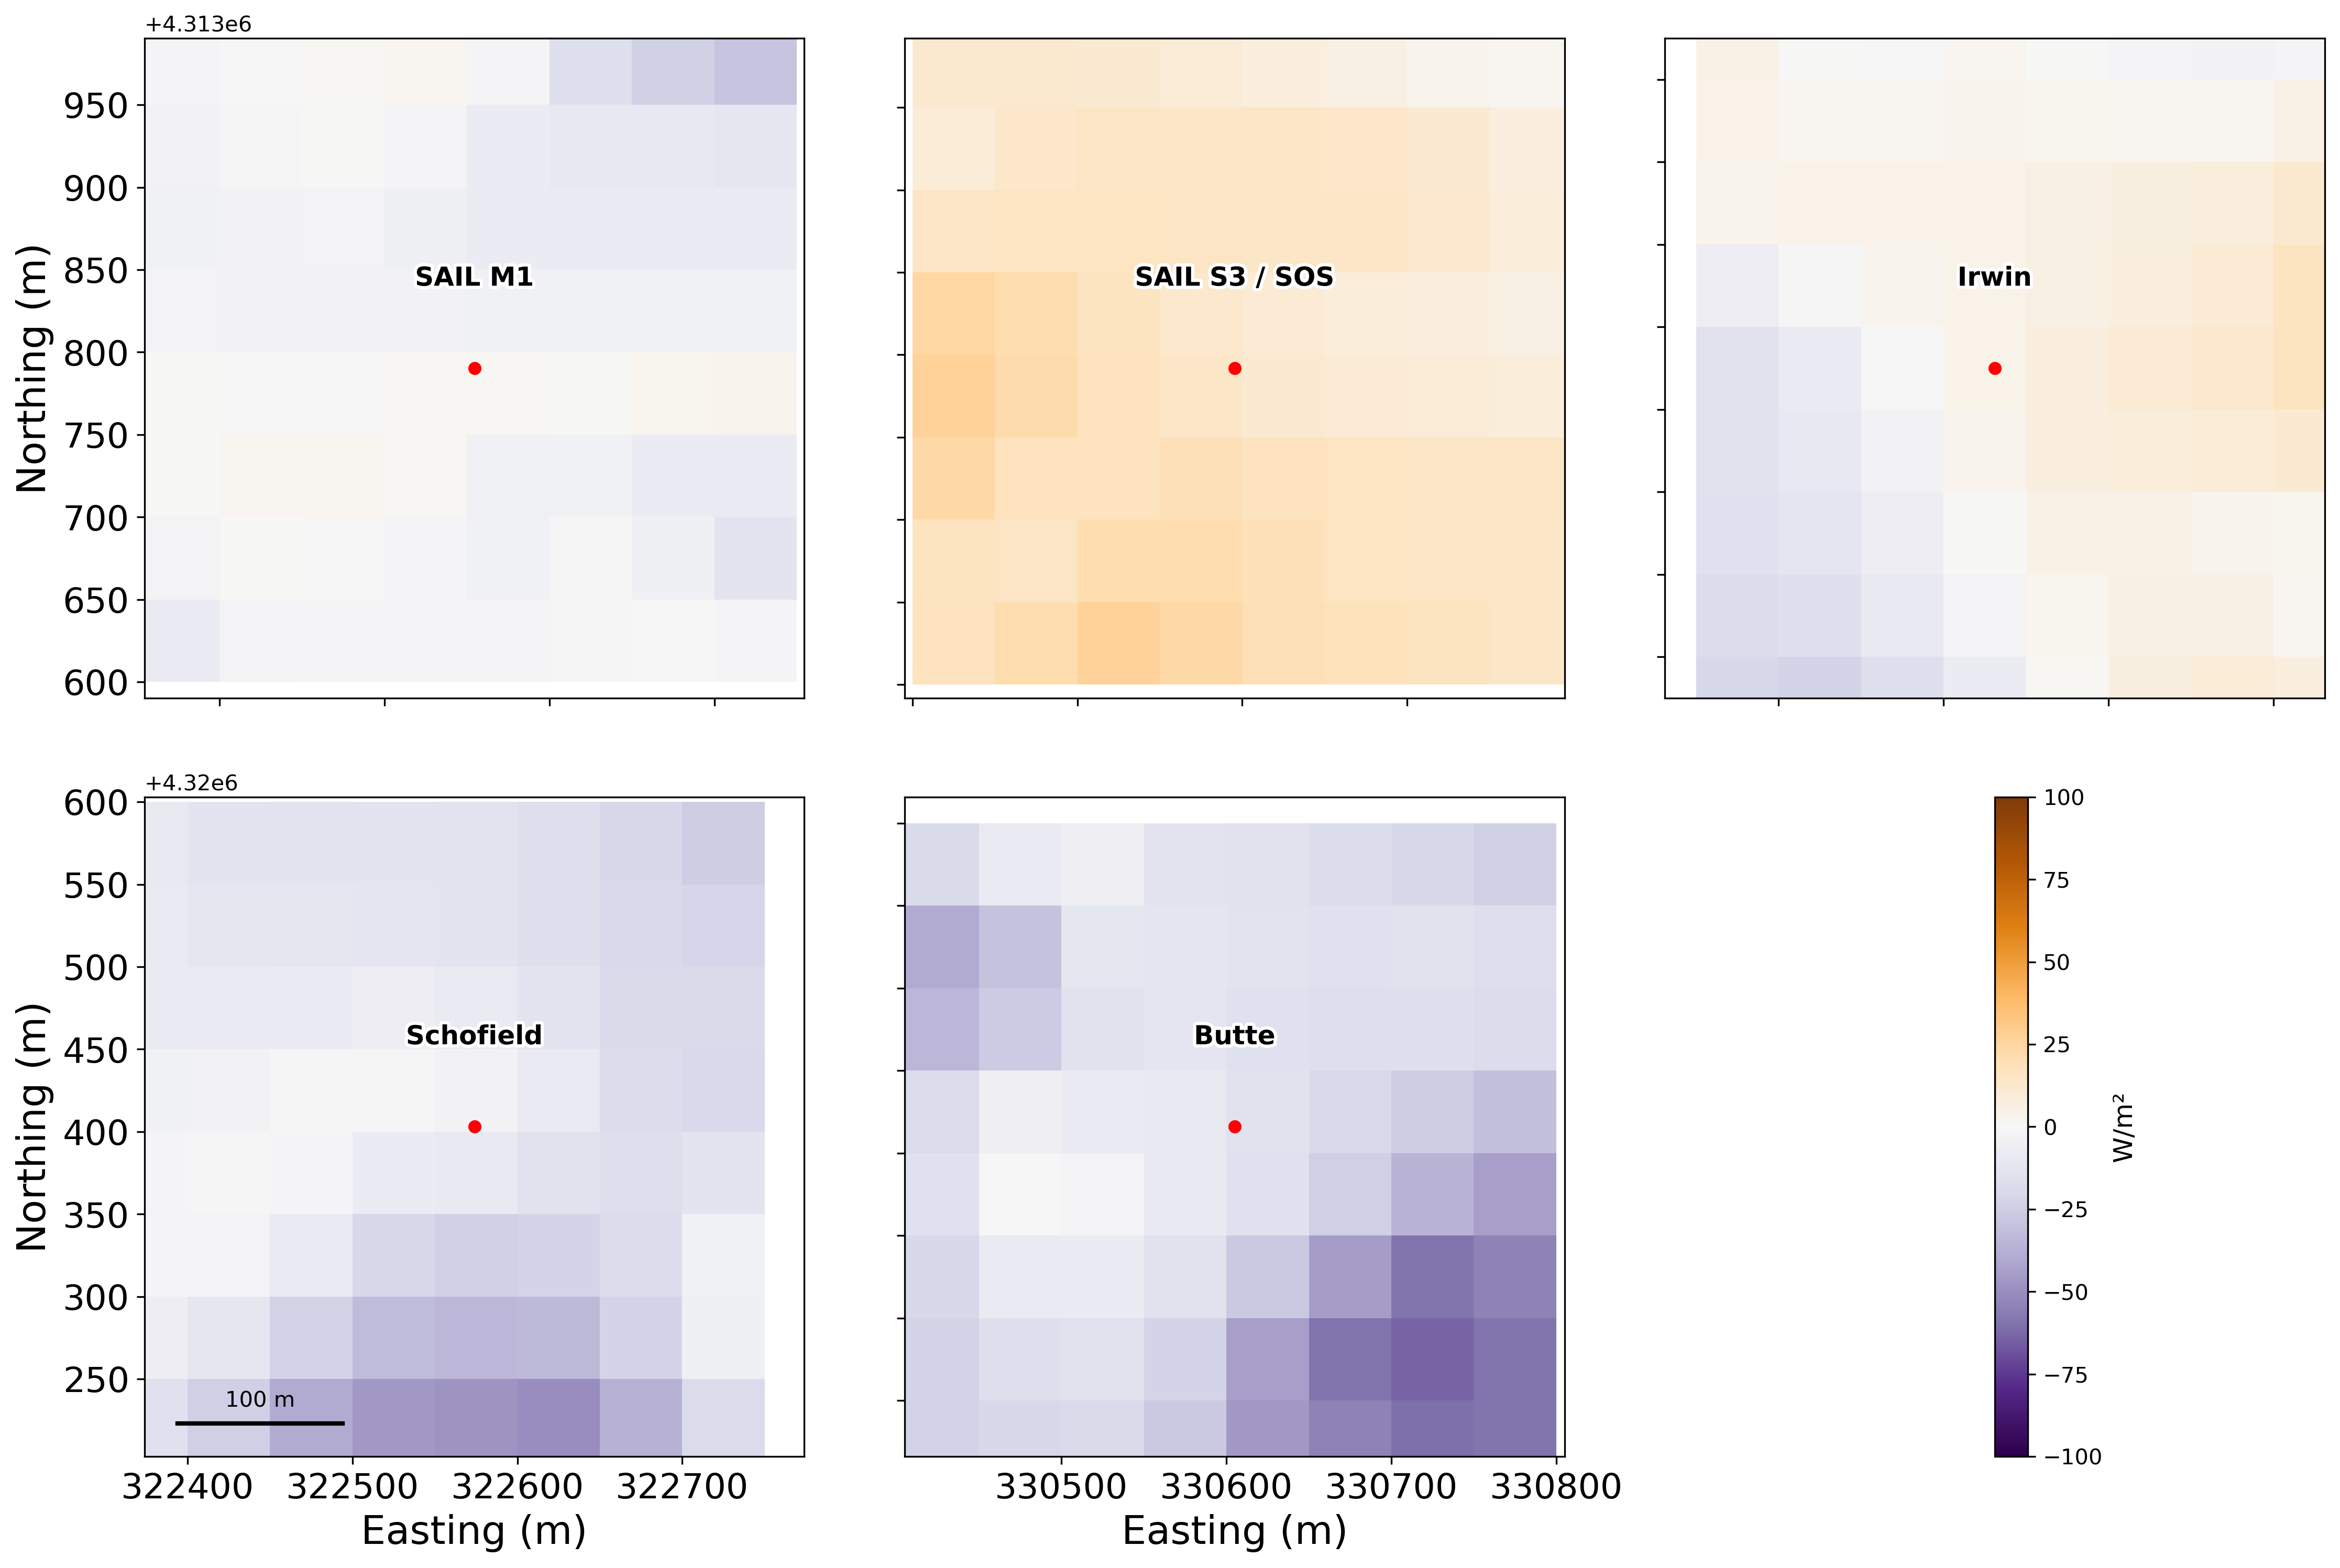

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import xarray as xr
import rioxarray
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches


dsw3_base = dsw3_base.assign_coords({
    "x": dsw3_base.coords["x"],
    "y": dsw3_base.coords["y"]
})




# -- CRS --
crs_utm13n = "EPSG:32613"

# -- Define ordered points --
ordered_points = {
    "SAIL M1": (327754.55, 4313790.30),
    "SAIL S3 / SOS": (328995.37, 4312141.89),
    "Irwin": (317131, 4306375),
    "Schofield": (322574, 4320403),
    "Butte": (330605, 4306866),
}

# -- Convert to GeoDataFrame --
gdf = gpd.GeoDataFrame({
    "name": list(ordered_points.keys()),
    "geometry": [Point(xy) for xy in ordered_points.values()]
}, crs=crs_utm13n)

# -- Ensure CRS is set on raster --
dsw3_base = dsw3_base.rio.write_crs(crs_utm13n)

# -- Plotting parameters --
vmin, vmax = -100, 100
abs_max = max(abs(vmin), abs(vmax))
cmap = 'PuOr_r'

# -- Set up subplots: 2 rows x 3 columns --
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10), dpi=300)
axes = axes.flatten()

# -- Site plotting order --
site_order = ["SAIL M1", "SAIL S3 / SOS", "Irwin", "Schofield", "Butte"]

# -- Label path effects --
label_effect = [path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()]

# -- Loop through sites --
for i, site_name in enumerate(site_order):
    ax = axes[i]
    
    point_geom = gdf.loc[gdf['name'] == site_name].geometry.values[0]
    x_center, y_center = point_geom.x, point_geom.y
    half_size = 200  # 400m total
    
    # -- Create square extent --
    extent_geom = box(x_center - half_size, y_center - half_size,
                      x_center + half_size, y_center + half_size)
    
    # -- Clip raster --
    dsw3_clipped = dsw3_base.rio.clip([extent_geom], crs=crs_utm13n)
        # Force correct coordinates again after clip
    # dsw3_clipped = dsw3_clipped.assign_coords({
    #     "x": dsw3_clipped.coords["x"],
    #     "y": dsw3_clipped.coords["y"]
    # })
    
    # Force spatial dimensions (this is the key fix)
    dsw3_clipped.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)


    # -- Plot raster --
    # dsw3_clipped.plot(ax=ax, cmap=cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=False)
    
    im = dsw3_clipped.plot(
    ax=ax,
    cmap=cmap,
    vmin=-abs_max,
    vmax=abs_max,
    add_colorbar=False,
    x='x',
    y='y'
    )
    ax.set_title("")  # Remove automatic title
    
    ax.set_ylim(sorted(ax.get_ylim()))  # Fix: y-axis so north is up
    ax.set_xlim(x_center - half_size, x_center + half_size)
    ax.set_aspect('equal')  # Optional: preserve scale

    ax.plot(x_center, y_center, marker='o', color='red', markersize=5)
    ax.text(x_center, y_center + 50, site_name, fontsize=12, fontweight='bold',
        color='black', ha='center', path_effects=label_effect)
    
    # -- Add scalebar (100 m) to bottom-left of each subplot --
    if i == 3:
        scalebar_length = 100  # meters
        bar_x = x_center - half_size + 20
        bar_y = y_center - half_size + 20
        ax.plot([bar_x, bar_x + scalebar_length], [bar_y, bar_y], color='black', lw=2)
        ax.text(bar_x + scalebar_length / 2, bar_y + 10, "100 m", fontsize=10, ha='center')


    # -- Axis formatting --
    ax.set_xlim(x_center - half_size, x_center + half_size)
    ax.set_ylim(y_center - half_size, y_center + half_size)

    ax.set_title("")  # Removes automatic DataArray name title

    
    
    
    # Axis formatting
    row, col = divmod(i, 3)
    if col != 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Northing (m)", fontsize=18)
    
    if row != 1:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Easting (m)", fontsize=18)
    
    ax.tick_params(labelsize=16)


# -- Add colorbar to 6th subplot (bottom right) --
cax = axes[5]
cax.axis('off')  # Hide content
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-abs_max, vmax=abs_max))
cb = fig.colorbar(sm, ax=cax, orientation='vertical', fraction=0.5)
cb.set_label('W/m²', fontsize=12)
cb.ax.tick_params(labelsize=10)

# -- Final layout --
plt.tight_layout()
plt.subplots_adjust(wspace=0.15, hspace=0.15)
plt.show()


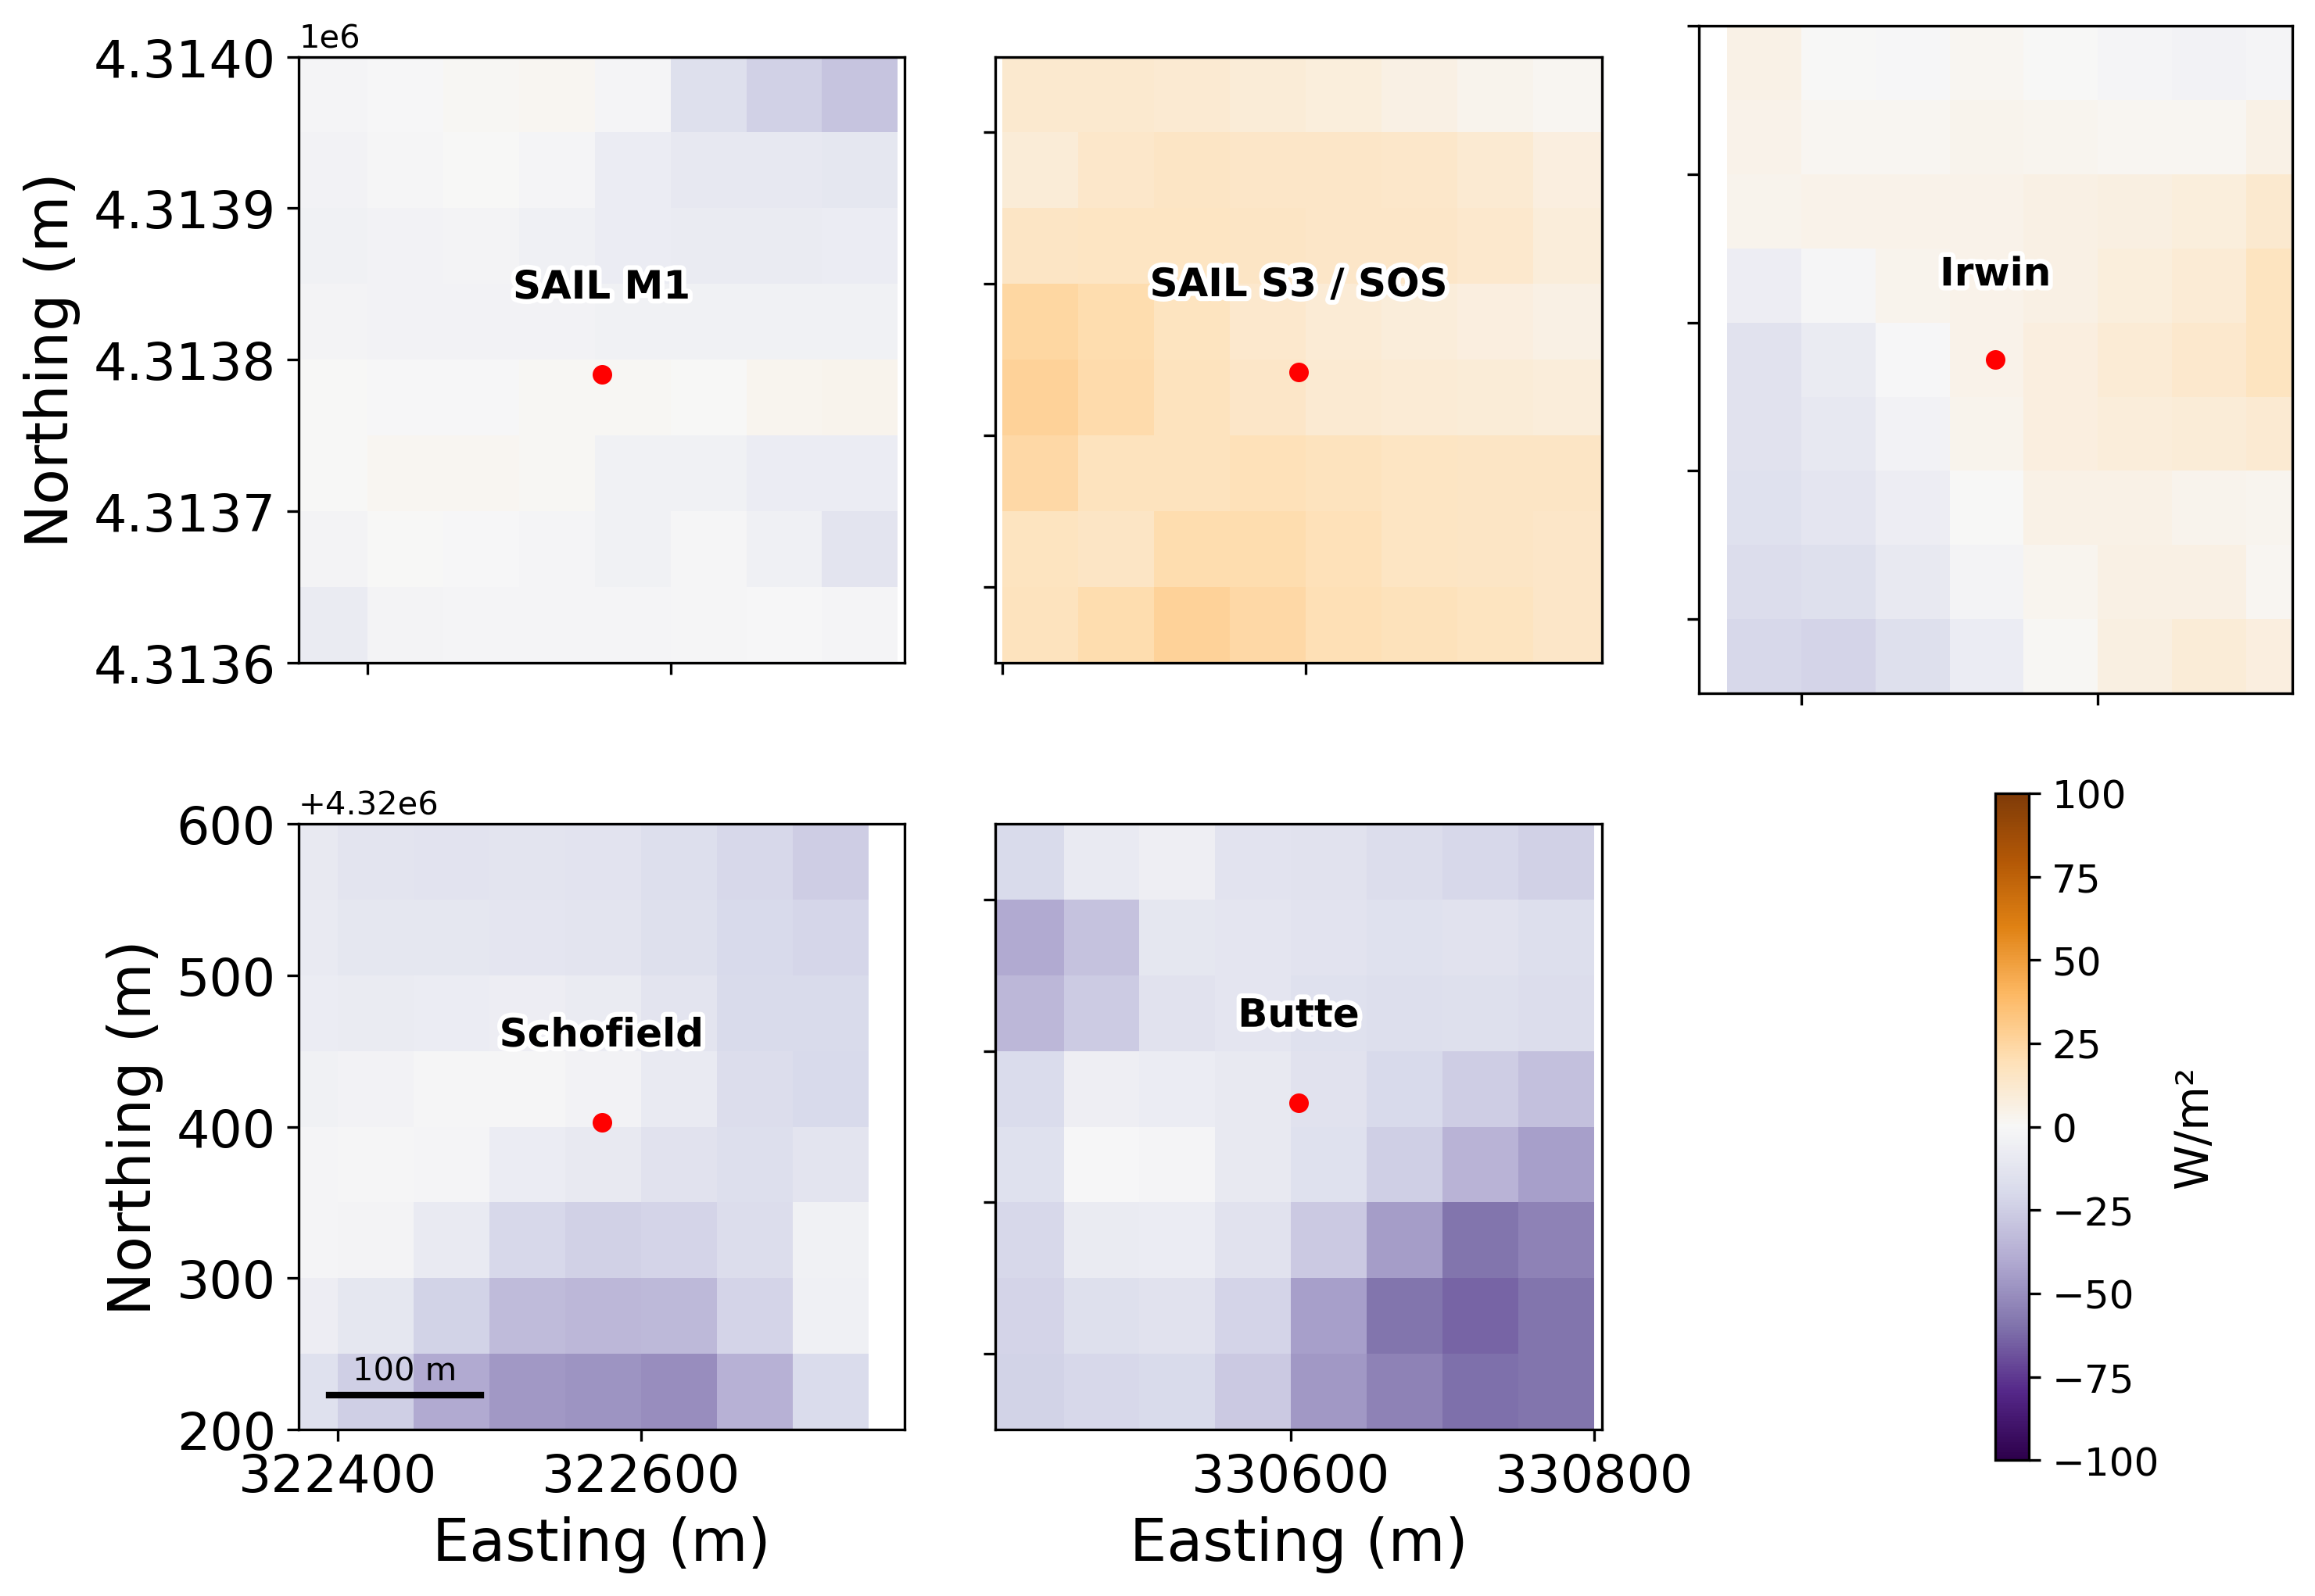

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import xarray as xr
import rioxarray
import matplotlib.patheffects as path_effects

# -- CRS --
crs_utm13n = "EPSG:32613"

# -- Define ordered points --
ordered_points = {
    "SAIL M1": (327754.55, 4313790.30),
    "SAIL S3 / SOS": (328995.37, 4312141.89),
    "Irwin": (317131, 4306375),
    "Schofield": (322574, 4320403),
    "Butte": (330605, 4306866),
}

# -- Convert to GeoDataFrame --
gdf = gpd.GeoDataFrame({
    "name": list(ordered_points.keys()),
    "geometry": [Point(xy) for xy in ordered_points.values()]
}, crs=crs_utm13n)

# -- Ensure CRS is set on raster --
dsw3_base = dsw3_base.assign_coords({
    "x": dsw3_base.coords["x"],
    "y": dsw3_base.coords["y"]
})
dsw3_base = dsw3_base.rio.write_crs(crs_utm13n)

# -- Plotting parameters --
vmin, vmax = -100, 100
abs_max = max(abs(vmin), abs(vmax))
cmap = 'PuOr_r'

# -- Set up subplots: 2 rows x 3 columns --
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 7), dpi=300)
axes = axes.flatten()

# -- Site plotting order --
site_order = ["SAIL M1", "SAIL S3 / SOS", "Irwin", "Schofield", "Butte"]

# -- Label path effects --
label_effect = [path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()]

# -- Loop through sites --
for i, site_name in enumerate(site_order):
    ax = axes[i]
    
    point_geom = gdf.loc[gdf['name'] == site_name].geometry.values[0]
    x_center, y_center = point_geom.x, point_geom.y
    half_size = 200  # 400m total

    # -- Create square extent --
    extent_geom = box(x_center - half_size, y_center - half_size,
                      x_center + half_size, y_center + half_size)

    # -- Clip raster with proper flag --
    dsw3_clipped = dsw3_base.rio.clip([extent_geom], crs=crs_utm13n, from_disk=True)
    dsw3_clipped.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

    # -- Plot clipped raster --
    dsw3_clipped.plot(
        ax=ax,
        cmap=cmap,
        vmin=-abs_max,
        vmax=abs_max,
        add_colorbar=False,
        x='x',
        y='y'
    )
    ax.set_ylim(sorted(ax.get_ylim()))
    ax.set_xlim(x_center - half_size, x_center + half_size)
    ax.set_aspect('equal')

    # -- Plot site marker --
    ax.plot(x_center, y_center, marker='o', color='red', markersize=5)
    ax.text(x_center, y_center + 50, site_name, fontsize=12, fontweight='bold',
            color='black', ha='center', path_effects=label_effect)

    # -- Add scalebar ONLY to bottom-left (i == 3) --
    if i == 3:
        scalebar_length = 100
        bar_x = x_center - half_size + 20
        bar_y = y_center - half_size + 20
        ax.plot([bar_x, bar_x + scalebar_length], [bar_y, bar_y], color='black', lw=2)
        ax.text(bar_x + scalebar_length / 2, bar_y + 10, "100 m", fontsize=10, ha='center')

    # -- Axis labels and ticks --
    ax.set_title("")  # Remove default title
    row, col = divmod(i, 3)
    if col != 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Northing (m)", fontsize=18)

    if row != 1:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Easting (m)", fontsize=18)

    ax.tick_params(labelsize=16)

    # Force correct y-axis tick labels for subplot 3 (bottom-left)
    # if i == 3:
    #     yticks = ax.get_yticks()  # Keep current tick positions
    #     ax.set_yticklabels([f"{int(tick):,}" for tick in yticks])

    # if i == 3:
    #     yticks = [4306200, 4306300, 4306400, 4306500]
    #     ax.set_yticks(yticks)
    #     ax.set_yticklabels([f"{tick:,}" for tick in yticks])




# -- Colorbar in last subplot --
cax = axes[5]
cax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-abs_max, vmax=abs_max))
cb = fig.colorbar(sm, ax=cax, orientation='vertical', fraction=0.5)
cb.set_label('W/m²', fontsize=14)
cb.ax.tick_params(labelsize=12)

# -- Final layout --
plt.tight_layout()
plt.subplots_adjust(wspace=0.15, hspace=0.15)
plt.show()



## add DEM

# Snow spatial